In [14]:
import numpy as np
import setup as stp
import Maxwell2D as Max
import mesh_reader as msh
import matplotlib.pyplot as plt

N = 8

dt0 = 1
cfs = np.array([dt0,dt0/2,dt0/4,dt0/8])

erros = []
for n in range(len(cfs)):
    VX, VY, EToV, BCTags = msh.MeshReader2D('malhas/h1.msh')

    malha = stp.StartUp2D(N,EToV,VX,VY)

    Ez = np.zeros((malha.Np,malha.K),dtype=np.float64)
    Ez = np.sin(malha.x)*np.sin(malha.y)
    Hx = np.zeros((malha.Np,malha.K), dtype=np.float64)
    Hy = np.zeros((malha.Np,malha.K),dtype= np.float64)

    FinalTime = 1.25 

    Hx, Hy, Ez, pp, t, erro = Max.Maxwell2D(Hx,Hy,Ez,FinalTime,malha,CFL=cfs[n],pml=False)

    Ez_analitico = np.sin(malha.x)*np.sin(malha.y)*np.cos(np.sqrt(2)*t[-1])

    M = np.linalg.inv(malha.V @ malha.V.T) 

    erro_nodal = Ez - Ez_analitico

    integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
    En = np.sqrt(integral_erro_sq)

    integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
    wt = np.sqrt(integral_analitico_sq)

    erro_L2_real = En / wt

    erros.append(erro_L2_real)

Malha carregada com sucesso!
Número de vértices: 441
Número de Elementos (K): 800
Tempo atual: 4.0526e-02 / 1.2500e+00
Tempo atual: 8.1053e-02 / 1.2500e+00
Tempo atual: 1.2158e-01 / 1.2500e+00
Tempo atual: 1.6211e-01 / 1.2500e+00
Tempo atual: 2.0263e-01 / 1.2500e+00
Tempo atual: 2.4316e-01 / 1.2500e+00
Tempo atual: 2.8368e-01 / 1.2500e+00
Tempo atual: 3.2421e-01 / 1.2500e+00
Tempo atual: 3.6474e-01 / 1.2500e+00
Tempo atual: 4.0526e-01 / 1.2500e+00
Tempo atual: 4.4579e-01 / 1.2500e+00
Tempo atual: 4.8632e-01 / 1.2500e+00
Tempo atual: 5.2684e-01 / 1.2500e+00
Tempo atual: 5.6737e-01 / 1.2500e+00
Tempo atual: 6.0789e-01 / 1.2500e+00
Tempo atual: 6.4842e-01 / 1.2500e+00
Tempo atual: 6.8895e-01 / 1.2500e+00
Tempo atual: 7.2947e-01 / 1.2500e+00
Tempo atual: 7.7000e-01 / 1.2500e+00
Tempo atual: 8.1053e-01 / 1.2500e+00
Tempo atual: 8.5105e-01 / 1.2500e+00
Tempo atual: 8.9158e-01 / 1.2500e+00
Tempo atual: 9.3210e-01 / 1.2500e+00
Tempo atual: 9.7263e-01 / 1.2500e+00
Tempo atual: 1.0132e+00 / 1.25

------------ N = 8 e 800 elementos ------------
Para CFL = 1.0 -> erro = 4.90e-10
Para CFL = 0.5 -> erro = 3.15e-11
Para CFL = 0.25 -> erro = 2.05e-12
Para CFL = 0.125 -> erro = 2.72e-13


Cálculo da Ordem do Runge-Kutta (q):
----------------------------------------
De CFL 1.000 para 0.500 -> Ordem q = 3.962
De CFL 0.500 para 0.250 -> Ordem q = 3.938
De CFL 0.250 para 0.125 -> Ordem q = 2.917


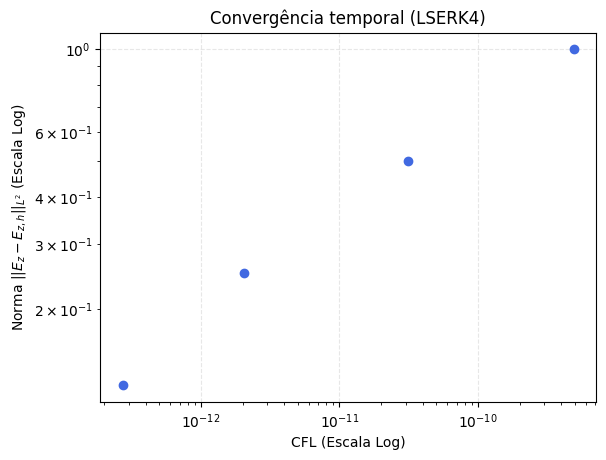

In [15]:
print(f'------------ N = {malha.N} e {malha.K} elementos ------------')
for i in range(len(cfs)):
    print(f'Para CFL = {cfs[i]} -> erro = {erros[i]:.2e}')

print('\n')

cfl_valores = np.array(cfs)

erros = np.array(erros)

print("Cálculo da Ordem do Runge-Kutta (q):")
print("-" * 40)

for i in range(len(cfl_valores) - 1):
    cfl_antigo = cfl_valores[i]
    cfl_novo = cfl_valores[i+1]
    
    E_antigo = erros[i]
    E_novo = erros[i+1]
    
    ordem_s = (np.log(E_novo) - np.log(E_antigo)) / (np.log(cfl_novo) - np.log(cfl_antigo))
    
    print(f"De CFL {cfl_antigo:.3f} para {cfl_novo:.3f} -> Ordem q = {ordem_s:.3f}")

plt.figure()
plt.grid(alpha=0.3,ls='--')
plt.title('Convergência temporal (LSERK4)')
plt.loglog(erros,cfs,'o',color='royalblue')
plt.xlabel('CFL (Escala Log)')
plt.ylabel(r'Norma $||E_z-E_{z,h}||_{L^2}$ (Escala Log)')
plt.show()